In [1]:
import torch
import torch.nn as nn
import gymnasium as gym
import numpy

from myrl.algorithms.ppo.model import ProximalPolicyOptimization
from myrl.algorithms.ppo.train import train_loop

In [7]:
env.action_space

Box(-3.0, 3.0, (1,), float32)

In [8]:
#env = gym.make("LunarLander-v3")
env = gym.make("CartPole-v1")
model = ProximalPolicyOptimization(
    obs_dim=env.observation_space.shape[0],
    actions_dim=env.action_space.n,
    n_hidden=2,
    hidden_dim=64,
)

# optimizer = PolicyGradientOptimizer(
#     parameters=model.parameters(),
#     alpha=1e-2
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=3e-4, 
    weight_decay=0.01
)

## Evaluation & Debugging Metrics
1. Episodic return
2. Approximate KL divergence (old policy vs new policy): expect ~0.01-0.02 per update
3. Clip fraction
4. Value function explained variance
5. Entropy
6. Loss components separately
7. Gradient norms
8. Advantage statistics
9. Ratio statistics (r_t = π_new/π_old)

In [4]:
losses_actor, losses_value, rewards = train_loop(
    model, 
    env, 
    optimizer, 
    n_episodes=10, 
    n_epochs=500,
    n_optim_epochs=3,
    n_optim_batch_size=64,
)

Epoch (0/500): Reward = 232.0, Loss Actor = -8.420798261960348, Loss Value = 202.40284474690756
Epoch (50/500): Reward = 4060.0, Loss Actor = -0.2784446998072478, Loss Value = 213.29597095648447
Epoch (100/500): Reward = 5000.0, Loss Actor = -0.8480721568759484, Loss Value = 562.8033103459998
Epoch (150/500): Reward = 5000.0, Loss Actor = -0.8462066730869471, Loss Value = 414.4104414992192
Epoch (200/500): Reward = 5000.0, Loss Actor = -0.21595359502462394, Loss Value = 468.2953378540554
Epoch (250/500): Reward = 5000.0, Loss Actor = -0.7838330018620954, Loss Value = 552.751089747948
Epoch (300/500): Reward = 5000.0, Loss Actor = -0.12437306146455718, Loss Value = 542.3560317156184
Epoch (350/500): Reward = 5000.0, Loss Actor = 0.020478777713161984, Loss Value = 548.550194140728
Epoch (400/500): Reward = 5000.0, Loss Actor = -0.762634564584066, Loss Value = 537.3997073274121
Epoch (450/500): Reward = 5000.0, Loss Actor = -0.9748339971786812, Loss Value = 379.80545777912386
Epoch (499/5

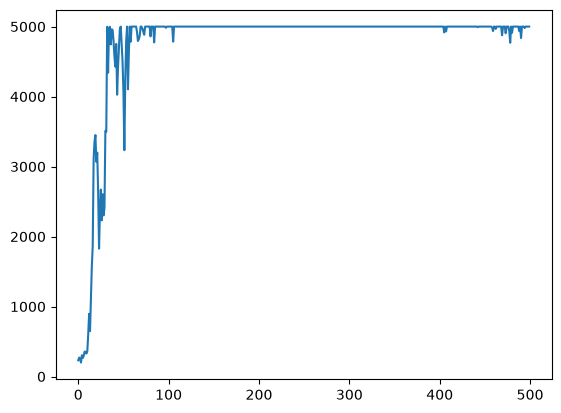

In [5]:
import matplotlib.pyplot as plt

plt.plot(rewards)

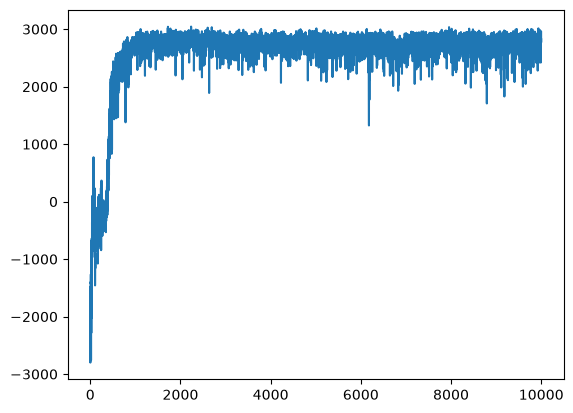

In [5]:
import matplotlib.pyplot as plt

plt.plot(rewards)

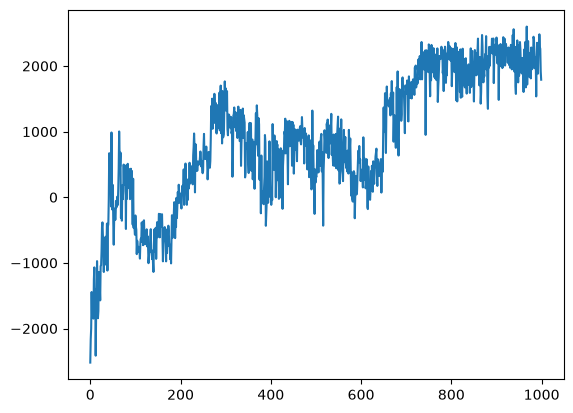

In [4]:
import matplotlib.pyplot as plt

plt.plot(rewards)

In [15]:
losses_actor, losses_value, rewards = train_loop(model, env, optimizer, n_episodes=10, n_epochs=1_000)

Epoch (0/1000): Reward = -1769.0613965770012, Loss Actor = -46.835872650146484, Loss Value = 2632.92822265625
Epoch (100/1000): Reward = -1556.557159538974, Loss Actor = -5.309576034545898, Loss Value = 584.6729736328125
Epoch (200/1000): Reward = -1427.4075259161316, Loss Actor = 8.135245323181152, Loss Value = 977.547607421875
Epoch (300/1000): Reward = -886.5475895427542, Loss Actor = -2.5129687786102295, Loss Value = 491.1719055175781
Epoch (400/1000): Reward = -404.67469127581774, Loss Actor = -3.5746142864227295, Loss Value = 228.01736450195312
Epoch (500/1000): Reward = -147.57598516077064, Loss Actor = 0.5567140579223633, Loss Value = 179.80784606933594
Epoch (600/1000): Reward = 4.555351149002092, Loss Actor = -1.2923566102981567, Loss Value = 171.3664093017578
Epoch (700/1000): Reward = 33.218149144641956, Loss Actor = -0.7100176215171814, Loss Value = 110.5740737915039
Epoch (800/1000): Reward = 54.40925765443694, Loss Actor = 1.7009211778640747, Loss Value = 88.089553833007

In [22]:
import pickle

In [23]:
with open('ppo-model-cartpole-20280908.pkl', 'wb') as f:
    pickle.dump(model, f)

In [11]:
with open('ppo-model-20280908.pkl', 'wb') as f:
    pickle.dump(model, f)

In [12]:
with open('ppo-rewards-20280908.pkl', 'wb') as f:
    pickle.dump(rewards, f)

In [24]:
with open('model/ppo-model-20280908.pkl', 'rb') as f:
    model_ll = pickle.load(f)

In [4]:
from torch.distributions.categorical import Categorical

def play(model, env, n_rounds, random=False):
    obs, _ = env.reset()
    done = False
    rounds = 0
    rewards_total = 0.0
    while not done:
        if not random:
            observations_tensor = torch.tensor(
                numpy.array(obs), 
                dtype=torch.float32
            )
            logits_actor, _ = model(observations_tensor)
            action = Categorical(logits=logits_actor).sample().item()
        else:
            action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if truncated:
            print(f"{truncated=}")
        if terminated:
            print(f"{terminated=}")
        
        rewards_total += reward
        if done:
            done = False
            rounds += 1
            print(f"{rewards_total=}")
            rewards_total = 0.0
            if rounds > n_rounds:
                done = True
            obs, _ = env.reset()
    env.close()

In [27]:
env = gym.make("LunarLander-v3", render_mode='human')
play(model_ll, env, n_rounds=10, random=True)

terminated=True
rewards_total=np.float64(-152.1281146997742)
terminated=True
rewards_total=np.float64(-70.82234611413622)
terminated=True
rewards_total=np.float64(-354.92944477366973)
terminated=True
rewards_total=np.float64(-423.156605598523)
terminated=True
rewards_total=np.float64(-389.4882980793767)
terminated=True
rewards_total=np.float64(-103.64991353157048)
terminated=True
rewards_total=np.float64(-281.23432027545545)
terminated=True
rewards_total=np.float64(8.805188610656145)
terminated=True
rewards_total=np.float64(-413.28197975570095)
terminated=True
rewards_total=np.float64(-96.02407658456939)
terminated=True
rewards_total=np.float64(-106.29906026884387)


In [28]:
env = gym.make("LunarLander-v3", render_mode='human')
play(model_ll, env, n_rounds=10)

terminated=True
rewards_total=np.float64(263.58916907230736)
terminated=True
rewards_total=np.float64(288.4417947828369)
terminated=True
rewards_total=np.float64(293.6964483724872)
terminated=True
rewards_total=np.float64(256.6135014429442)
terminated=True
rewards_total=np.float64(304.61476510880516)
terminated=True
rewards_total=np.float64(251.45463084865807)
terminated=True
rewards_total=np.float64(285.15924091127164)
terminated=True
rewards_total=np.float64(272.44812111409567)
terminated=True
rewards_total=np.float64(304.73351707259553)
terminated=True
rewards_total=np.float64(293.2761451697355)
terminated=True
rewards_total=np.float64(294.8161537253154)


In [21]:
env = gym.make("CartPole-v1", render_mode='human')
play(model, env, n_rounds=10)

truncated=True
rewards_total=500.0
terminated=True
rewards_total=419.0
truncated=True
rewards_total=500.0
truncated=True
rewards_total=500.0
truncated=True
rewards_total=500.0
truncated=True
rewards_total=500.0
truncated=True
rewards_total=500.0
truncated=True
rewards_total=500.0
terminated=True
rewards_total=466.0
truncated=True
rewards_total=500.0
truncated=True
rewards_total=500.0


In [5]:
env = gym.make("CartPole-v1", render_mode='human')
play(model, env, n_rounds=10, random=True)

terminated=True
rewards_total=17.0
terminated=True
rewards_total=16.0
terminated=True
rewards_total=11.0
terminated=True
rewards_total=16.0
terminated=True
rewards_total=28.0
terminated=True
rewards_total=21.0
terminated=True
rewards_total=17.0
terminated=True
rewards_total=15.0
terminated=True
rewards_total=31.0
terminated=True
rewards_total=27.0
terminated=True
rewards_total=34.0
